In [1]:
import warnings
warnings.filterwarnings('ignore')

from flonacomldft.utils.io_utils import (
    load_pickle_file, 
    get_project_path,
    save_pickle_file,
    load_csv_file,
)

import json
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from flonacomldft.utils.plots import set_plot_sequential_data
import matplotlib.pylab as pylab
from ase.units import kB

size=14
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [4]:
project_path = get_project_path()

sims_path = ['1-adaptive']*16 + ['2-adaptive-mlp']*16

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4 + [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)] + [int('3001962{:d}'.format(i)) for i in range(8)] + [int('3000710{:d}'.format(i)) for i in range(8)]

In [6]:
accs_info = []

for isomer, number_id, sim_path in zip(isomers, number_ids, sims_path):
    folder = 'results_adaptive_is{:d}_{:d}'.format(isomer, number_id)
    accs_file = 'accs_is{:d}_{:d}.csv'.format(isomer, number_id)
    #part_ratios_file = '/part_ratios_is{:d}_{:d}.csv'.format(isomer, number_id)
    args_file = 'args_adaptive_sampling_{:d}.json'.format(number_id)
    acc = load_csv_file(accs_file, project_path + '/' + sim_path + '/' + folder)
    f = open(project_path + '/' + sim_path + '/' + folder + '/' + args_file)
    data = json.load(f)
    data['accs'] = acc[:, 0].detach().numpy()
    accs_info.append(data)

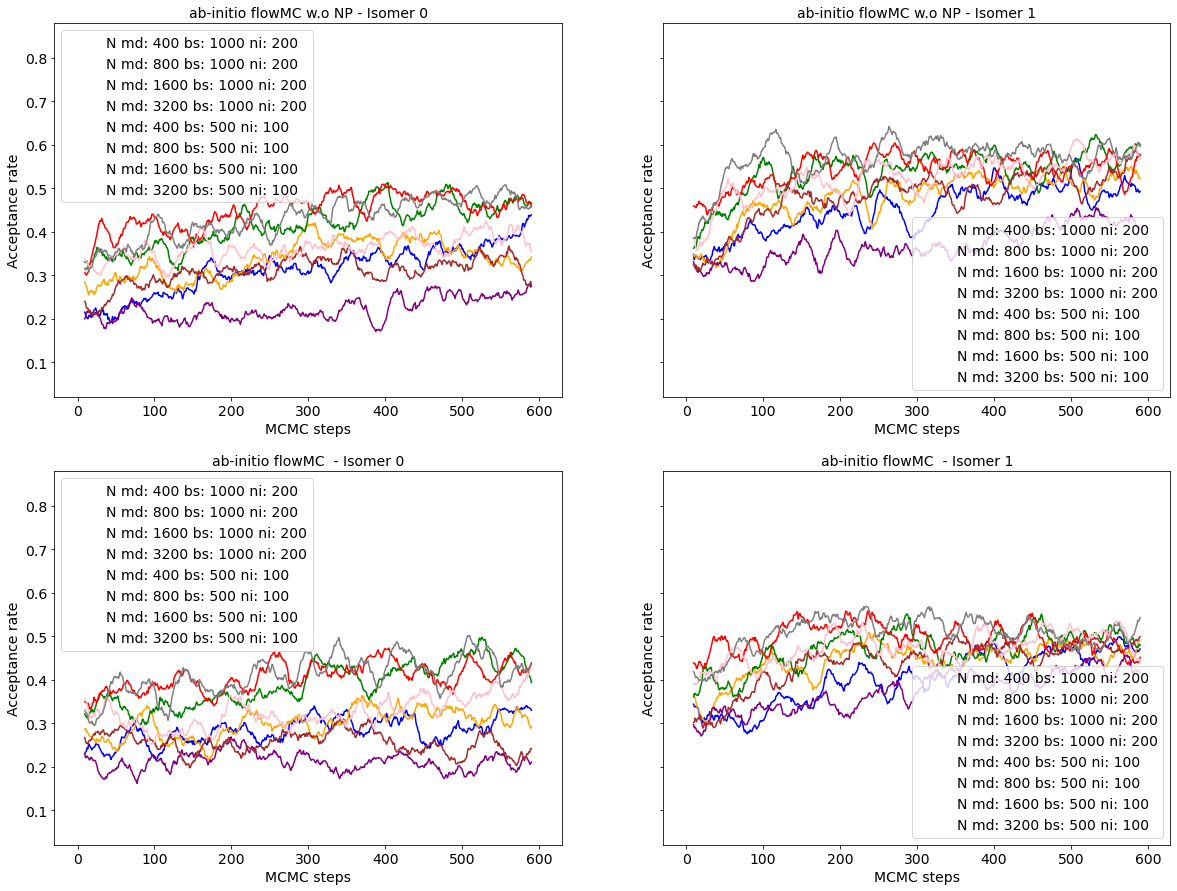

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharey=True)
fig.subplots_adjust(top=0.94)

c1 = ['blue', 'orange', 'green', 'red', 'blue', 'orange', 'green', 'red']
c2 = ['purple', 'brown', 'pink', 'gray', 'purple', 'brown', 'pink', 'gray']
colors = c1 + c2

for j in range(2):
    for i, acc_info in enumerate(accs_info[16*j:16*j+16]):

        isomer_label = acc_info['isomer_label'][0]

        label  = 'N md: {:d} bs: {:d} ni: {:d}'.format(int(acc_info['N']*0.8),
                                                    acc_info['flow_batch_size'],
                                                    acc_info['flow_n_iter'])

        color_value = colors[i]
        set_plot_sequential_data(acc_info['accs'], 
                                 avg=True, 
                                 window_size=20, 
                                 alpha=0.0, 
                                 color=color_value, 
                                 ax=axs[j][isomer_label], 
                                 label=label)

        if j == 0:
            add = 'w.o NP'
        else:
            add = ''

        axs[j][isomer_label].legend()
        axs[j][isomer_label].set_xlabel('MCMC steps')
        axs[j][isomer_label].set_ylabel('Acceptance rate')
        axs[j][isomer_label].set_title('ab-initio flowMC {:s} - Isomer {:d}'.format(add, isomer_label))